# Notebook de validação dos sinais de qualificação de engajamento

- Dataset de entrada: posts_processado.parquet

In [32]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
from scipy.stats import spearmanr, kruskal
from itertools import product as iproduct

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [3]:
ORDEM_BUCKET   = ["nano", "micro", "mid-tier", "macro", "mega"]
ORDEM_LABEL    = ["LOW", "MEDIUM", "HIGH", "VIRAL"]
ORDEM_IQA      = ["LOW", "MEDIUM", "HIGH", "VIRAL"]

In [4]:
df_posts = pl.read_parquet('posts_processado.parquet')
df_cv = pl.read_parquet('influenciadores_cv.parquet')

In [10]:
df_cv.columns

['username',
 'er_media',
 'er_std',
 'er_mediana',
 'er_p25',
 'er_p75',
 'n_posts_validos',
 'categoria',
 'followers',
 'bucket_followers',
 'cv_er']

## 0.1 Construção do Ground Truth
Referencia para avaliar o se o IQA classifica bem os influenciadores. Vamos fazer um performance_label por influenciador = bucket do er mediano do influenciador dentro do segmento de followers, usando os thresholds percentis(p25/p275/p90)

- Usa o adapted_bucket_pct já validado no processamento
- Relativo ao seguimento, um er de 3% é MEDIUM para Nano mas High para mega
- É independente de IQA, não usa CV nem patrocínio

In [12]:
thresholds_gt = (
    df_posts.filter(
        (pl.col("er_classico") > 0) &
        (pl.col("er_classico") < 100)
    )
    .group_by("bucket_followers")
    .agg([
        pl.col("er_classico").quantile(0.25).alias("p25"),
        pl.col("er_classico").quantile(0.75).alias("p75"),
        pl.col("er_classico").quantile(0.90).alias("p90"),
        pl.col("er_classico").median().alias("mediana"),
        pl.len().alias("n_posts"),
    ])
    .sort(pl.col("bucket_followers").cast(pl.Enum(ORDEM_BUCKET)))
)
print("Thresholds do ground truth (percentis por segmento):")
print(thresholds_gt)

Thresholds do ground truth (percentis por segmento):
shape: (5, 6)
┌──────────────────┬──────────┬──────────┬───────────┬──────────┬─────────┐
│ bucket_followers ┆ p25      ┆ p75      ┆ p90       ┆ mediana  ┆ n_posts │
│ ---              ┆ ---      ┆ ---      ┆ ---       ┆ ---      ┆ ---     │
│ str              ┆ f64      ┆ f64      ┆ f64       ┆ f64      ┆ u32     │
╞══════════════════╪══════════╪══════════╪═══════════╪══════════╪═════════╡
│ nano             ┆ 1.886792 ┆ 6.772811 ┆ 11.025145 ┆ 3.717827 ┆ 3521107 │
│ micro            ┆ 1.426703 ┆ 4.80336  ┆ 7.772482  ┆ 2.710101 ┆ 4477429 │
│ mid-tier         ┆ 1.280946 ┆ 4.292392 ┆ 7.20556   ┆ 2.404068 ┆ 1156679 │
│ macro            ┆ 1.060649 ┆ 4.346021 ┆ 7.359569  ┆ 2.288757 ┆ 193495  │
│ mega             ┆ 0.998368 ┆ 4.044924 ┆ 6.593368  ┆ 2.147214 ┆ 213358  │
└──────────────────┴──────────┴──────────┴───────────┴──────────┴─────────┘


In [13]:
df_gt = (
    df_posts.filter(pl.col("er_classico") > 0)
    .group_by("username")
    .agg([
        pl.col("er_classico").median().alias("er_cl_mediano"),
        pl.col("er_weighted").median().alias("er_wt_mediano"),
        pl.col("inf_category").first().alias("categoria"),
        pl.col("bucket_followers").first().alias("bucket_followers"),
        pl.col("followers").first().alias("followers"),
        pl.col("is_sponsored").mean().round(4).alias("pct_sponsored"),
        pl.len().alias("n_posts"),
    ])
    .join(thresholds_gt.select(["bucket_followers","p25","p75","p90"]),
          on="bucket_followers", how="left")
    .with_columns(
        pl.when(pl.col("er_cl_mediano") < pl.col("p25"))  .then(pl.lit("LOW"))
        .when(pl.col("er_cl_mediano") < pl.col("p75"))    .then(pl.lit("MEDIUM"))
        .when(pl.col("er_cl_mediano") < pl.col("p90"))    .then(pl.lit("HIGH"))
        .otherwise(                                         pl.lit("VIRAL"))
        .alias("performance_label")
    )
    .drop(["p25", "p75", "p90"])
)

print(f"Influenciadores com ground truth: {df_gt.shape[0]:,}")

Influenciadores com ground truth: 33,148


- Distribuição do GT

In [17]:
dist_gt = (
    df_gt.group_by("performance_label")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / df_gt.shape[0] * 100).round(1).alias("pct"))
    .sort(pl.col("performance_label").cast(pl.Enum(ORDEM_LABEL)))
)
dist_gt

performance_label,n,pct
str,u32,f64
"""LOW""",7124,21.5
"""MEDIUM""",19011,57.4
"""HIGH""",5015,15.1
"""VIRAL""",1998,6.0


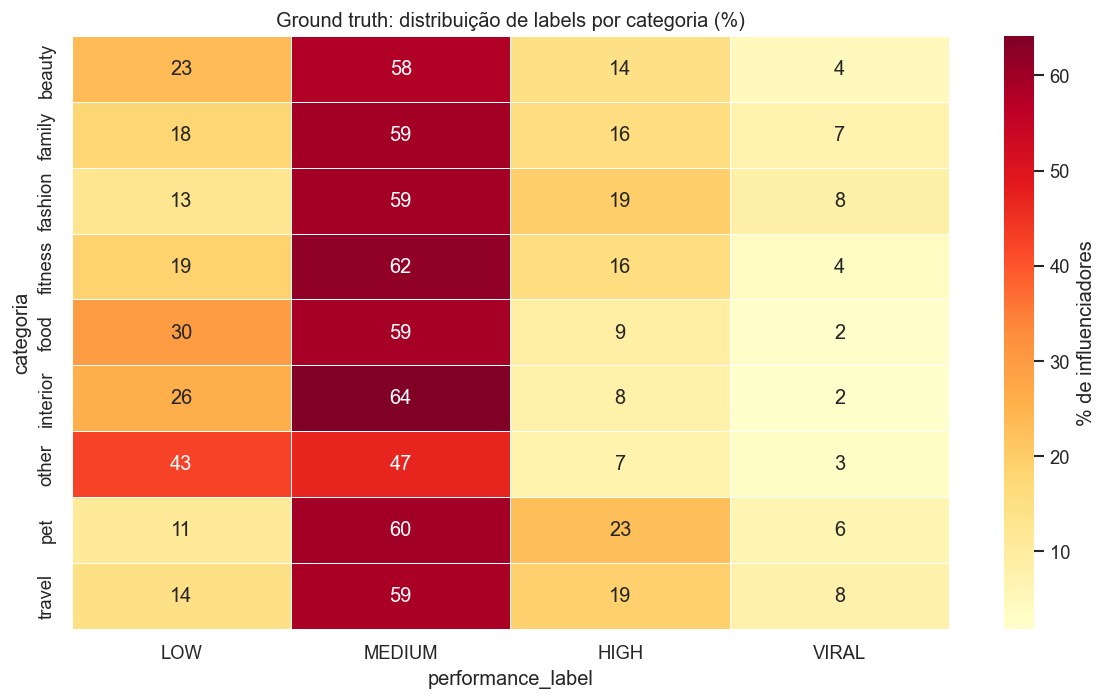

In [18]:
pivot_gt = (
    df_gt.group_by(["categoria", "bucket_followers", "performance_label"])
    .agg(pl.len().alias("n"))
    .to_pandas()
    .pivot_table(index="categoria", columns="performance_label",
                 values="n", fill_value=0, aggfunc="sum")
    .reindex(columns=ORDEM_LABEL, fill_value=0)
)
pivot_gt_pct = pivot_gt.div(pivot_gt.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_gt_pct, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.3, cbar_kws={"label": "% de influenciadores"})
ax.set_title("Ground truth: distribuição de labels por categoria (%)")
plt.tight_layout()
plt.show()

# 1.0 Validação do er_weighted

er_weighted diferencia influenciadores melhor do que er_classico?

## 1.1 Comparação er_weighted vs er_classico

In [25]:
er_pd = df_gt[["er_cl_mediano", "er_wt_mediano"]].to_pandas()

r_global, p_global = spearmanr(er_pd["er_cl_mediano"], er_pd["er_wt_mediano"])
print(f"Correlação Spearman (global): r={r_global:.4f}, p={p_global:.2e}")

# Subconjunto: influenciadores onde er_wt > er_cl (têm comentários relevantes)
df_gt_com = df_gt.filter(pl.col("er_wt_mediano") > pl.col("er_cl_mediano"))
er_pd_com = df_gt_com[["er_cl_mediano", "er_wt_mediano"]].to_pandas()
r_com, p_com = spearmanr(er_pd_com["er_cl_mediano"], er_pd_com["er_wt_mediano"])
print(f"Correlação Spearman (com comentários): r={r_com:.4f}, p={p_com:.2e}")
print(f"Influenciadores onde er_wt > er_cl: {df_gt_com.shape[0]} ({df_gt_com.shape[0]/df_gt.shape[0]*100:.1f}%)")


Correlação Spearman (global): r=1.0000, p=0.00e+00
Correlação Spearman (com comentários): r=1.0000, p=0.00e+00
Influenciadores onde er_wt > er_cl: 16277 (49.1%)


- Mudança de label: quantos influenciadores mudariam de performance_label se usássemos er_wt_mediano em vez de er_cl_mediano para o ground truth?

In [29]:
df_gt_comp = (
    df_gt
    .join(thresholds_gt.select(["bucket_followers","p25","p75","p90"]),
          on="bucket_followers", how="left")
    .with_columns(
        pl.when(pl.col("er_wt_mediano") < pl.col("p25"))  .then(pl.lit("LOW"))
        .when(pl.col("er_wt_mediano") < pl.col("p75"))    .then(pl.lit("MEDIUM"))
        .when(pl.col("er_wt_mediano") < pl.col("p90"))    .then(pl.lit("HIGH"))
        .otherwise(                                         pl.lit("VIRAL"))
        .alias("label_wt")
    )
)
mudancas = df_gt_comp.filter(pl.col("performance_label") != pl.col("label_wt")).shape[0]
print(f"\nMudanças de label se usar er_wt: {mudancas:,} ({mudancas/df_gt.shape[0]*100:.1f}%)")


Mudanças de label se usar er_wt: 123 (0.4%)


Mudança muito pequena, er_weighted não altera ranking significativamente

- Scatter er_classico vs er_weighetd

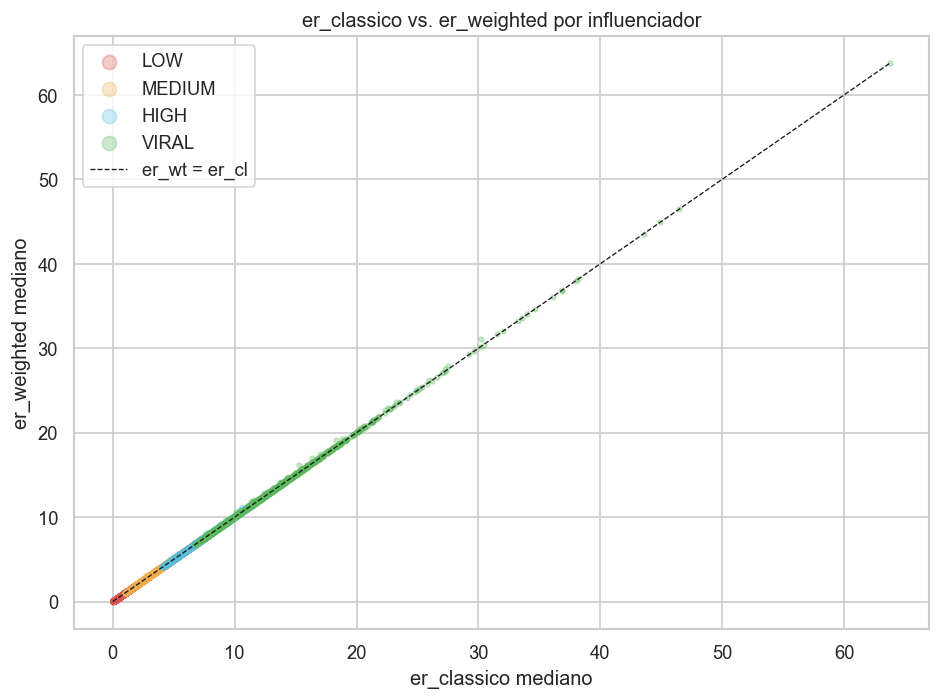

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
cores_label = {"LOW": "#d9534f", "MEDIUM": "#f0ad4e",
               "HIGH": "#5bc0de", "VIRAL": "#5cb85c"}
for label in ORDEM_LABEL:
    sub = df_gt.filter(pl.col("performance_label") == label).to_pandas()
    ax.scatter(sub["er_cl_mediano"], sub["er_wt_mediano"],
               alpha=0.3, s=8, color=cores_label[label], label=label)
lim = max(df_gt["er_cl_mediano"].max(), df_gt["er_wt_mediano"].max())
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="er_wt = er_cl")
ax.set_xlabel("er_classico mediano")
ax.set_ylabel("er_weighted mediano")
ax.set_title("er_classico vs. er_weighted por influenciador")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

# 1.2 Grid Search de pesos

Qual combinação de pesos separa melhor os labels?

Métrica de separação: estatistica H de Kruskal-Wallis entre os grupos LOW/MEDIUM/HIGH/VIRAL
 - H maior = melhor separação, distribuições de er entre grupos são distintas
 - Pesos testados: w_likes ∈ {0.5, 1.0, 1.5} × w_comments ∈ {1.0, 1.5, 2.0, 2.5, 3.0}.

In [40]:
W_LIKES    = [0.5,1.0,1.5,2.0,2.5,3]
W_COMMENTS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

resultados_grid = []

for wl, wc in iproduct(W_LIKES, W_COMMENTS):
    # Calcula er com esses pesos ao nível do post
    er_tmp = (
        df_posts.filter(pl.col("followers") > 0)
        .with_columns(
            ((pl.col("likes") * wl + pl.col("comments_count") * wc) / pl.col("followers") * 100)
            .alias("er_tmp")
        )
        .group_by("username")
        .agg(pl.col("er_tmp").median().alias("er_tmp_mediano"))
    )
    # Junta com ground truth
    merged = (
        df_gt.select(["username", "performance_label"])
        .join(er_tmp, on="username", how="left")
        .filter(pl.col("er_tmp_mediano").is_not_null())
        .to_pandas()
    )
    # Kruskal-Wallis entre grupos
    grupos = [merged[merged["performance_label"] == l]["er_tmp_mediano"].values
              for l in ORDEM_LABEL if len(merged[merged["performance_label"] == l]) > 0]
    if len(grupos) < 2:
        continue
    H, p = kruskal(*grupos)
    resultados_grid.append({"w_likes": wl, "w_comments": wc, "H": round(H, 2), "p": p})

df_grid = pd.DataFrame(resultados_grid).sort_values("H", ascending=False)
print("Grid search — separação por combinação de pesos (H de Kruskal-Wallis):")
print(df_grid.to_string(index=False))
print()
melhor = df_grid.iloc[0]
print(f"Melhor combinação: w_likes={melhor.w_likes}, w_comments={melhor.w_comments}  (H={melhor.H:.2f})")
print(f"Combinação proposta (1, 2):           H={df_grid[df_grid.w_comments==2.0].iloc[0]['H']:.2f}")

Grid search — separação por combinação de pesos (H de Kruskal-Wallis):
 w_likes  w_comments        H   p
     3.0         0.5 25173.62 0.0
     2.5         0.5 25173.16 0.0
     2.0         0.5 25172.46 0.0
     1.5         0.5 25171.34 0.0
     3.0         1.0 25171.34 0.0
     2.5         1.0 25170.45 0.0
     3.0         1.5 25168.54 0.0
     2.0         1.0 25168.54 0.0
     1.0         0.5 25168.54 0.0
     2.5         1.5 25166.74 0.0
     1.5         1.0 25165.64 0.0
     3.0         2.0 25165.64 0.0
     2.0         1.5 25164.47 0.0
     2.5         2.0 25163.80 0.0
     3.0         2.5 25163.44 0.0
     2.5         2.5 25160.73 0.0
     1.5         1.5 25160.73 0.0
     1.0         1.0 25160.73 0.0
     0.5         0.5 25160.73 0.0
     3.0         3.0 25160.73 0.0
     2.0         2.0 25160.73 0.0
     2.5         3.0 25157.73 0.0
     2.0         2.5 25156.99 0.0
     3.0         4.0 25155.77 0.0
     1.5         2.0 25155.77 0.0
     1.0         1.5 25153.06 0.0
     2.0   

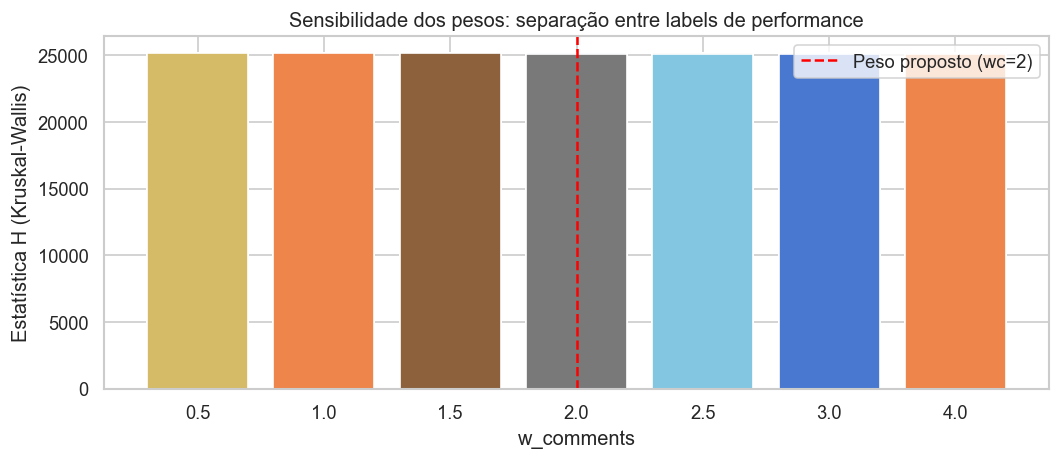

In [43]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_grid["w_comments"].astype(str),
       df_grid["H"],
       color=sns.color_palette("muted", len(df_grid)))
ax.axvline(df_grid[df_grid["w_comments"] == 2.0].index[0] -
           df_grid.index[0], color="red", linestyle="--",
           label="Peso proposto (wc=2)")
ax.set_xlabel("w_comments")
ax.set_ylabel("Estatística H (Kruskal-Wallis)")
ax.set_title("Sensibilidade dos pesos: separação entre labels de performance")
ax.legend()
plt.tight_layout()
plt.show()

## 1.3 Quando o peso vencedor faz diferença?

In [36]:
df_gt_diff = df_gt.with_columns(
    (pl.col("er_wt_mediano") - pl.col("er_cl_mediano")).alias("er_diff")
)

perfil_diff = (
    df_gt_diff
    .group_by(["categoria", "bucket_followers"])
    .agg([
        pl.col("er_diff").median().round(4).alias("diff_mediana"),
        pl.col("er_diff").mean().round(4).alias("diff_media"),
        (pl.col("er_diff") > 0).sum().alias("n_com_diff"),
        pl.len().alias("n_total"),
    ])
    .with_columns(
        (pl.col("n_com_diff") / pl.col("n_total") * 100).round(1).alias("pct_com_diff")
    )
    .sort("diff_mediana", descending=True)
)
print("Diferença er_wt - er_cl por categoria e segmento:")
print(perfil_diff)
print()
print("Categorias com maior diferença = audiência mais ativa (mais comentários relativos).")

Diferença er_wt - er_cl por categoria e segmento:
shape: (45, 7)
┌───────────┬──────────────────┬──────────────┬────────────┬────────────┬─────────┬──────────────┐
│ categoria ┆ bucket_followers ┆ diff_mediana ┆ diff_media ┆ n_com_diff ┆ n_total ┆ pct_com_diff │
│ ---       ┆ ---              ┆ ---          ┆ ---        ┆ ---        ┆ ---     ┆ ---          │
│ str       ┆ str              ┆ f64          ┆ f64        ┆ u32        ┆ u32     ┆ f64          │
╞═══════════╪══════════════════╪══════════════╪════════════╪════════════╪═════════╪══════════════╡
│ fashion   ┆ nano             ┆ 0.011        ┆ 0.028      ┆ 1669       ┆ 3063    ┆ 54.5         │
│ interior  ┆ nano             ┆ 0.0105       ┆ 0.0212     ┆ 202        ┆ 364     ┆ 55.5         │
│ food      ┆ nano             ┆ 0.0058       ┆ 0.0211     ┆ 746        ┆ 1466    ┆ 50.9         │
│ family    ┆ micro            ┆ 0.0045       ┆ 0.0128     ┆ 936        ┆ 1601    ┆ 58.5         │
│ pet       ┆ micro            ┆ 0.0044     

# 2.0 Validação do f_cv

f_cv = 1/(1+CV/100)

Hipotese: influenciadores com CV alto têm engajamento menos previsivel, logo deveriam receber uma penalidade.

## 2.1 Distribuição do CV

In [45]:
df_val = (
    df_gt
    .join(
        df_cv.select(["username", "cv_er"]),
        on="username", how="left"
    )
)

sem_cv = df_val.filter(pl.col("cv_er").is_null()).shape[0]
print(f"Influenciadores sem CV: {sem_cv}")

# Distribuição do CV por segmento
cv_seg = (
    df_val.filter(pl.col("cv_er").is_not_null())
    .group_by("bucket_followers")
    .agg([
        pl.col("cv_er").median().round(2).alias("cv_mediano"),
        pl.col("cv_er").mean().round(2).alias("cv_medio"),
        pl.col("cv_er").quantile(0.75).round(2).alias("cv_p75"),
        pl.len().alias("n"),
    ])
    .sort(pl.col("bucket_followers").cast(pl.Enum(ORDEM_BUCKET)))
)
print("\nCV do ER por segmento de followers:")
cv_seg

Influenciadores sem CV: 35

CV do ER por segmento de followers:


bucket_followers,cv_mediano,cv_medio,cv_p75,n
str,f64,f64,f64,u32
"""nano""",49.19,57.52,67.29,12261
"""micro""",50.17,57.03,67.64,15454
"""mid-tier""",50.05,56.61,68.0,3992
"""macro""",55.0,62.19,76.85,668
"""mega""",59.92,64.79,79.16,738


C:\Users\cruzd\AppData\Local\Temp\ipykernel_14888\3294897296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cv_pd, x="bucket_followers", y="cv_clip",
C:\Users\cruzd\AppData\Local\Temp\ipykernel_14888\3294897296.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cv_pd, x="performance_label", y="cv_clip",


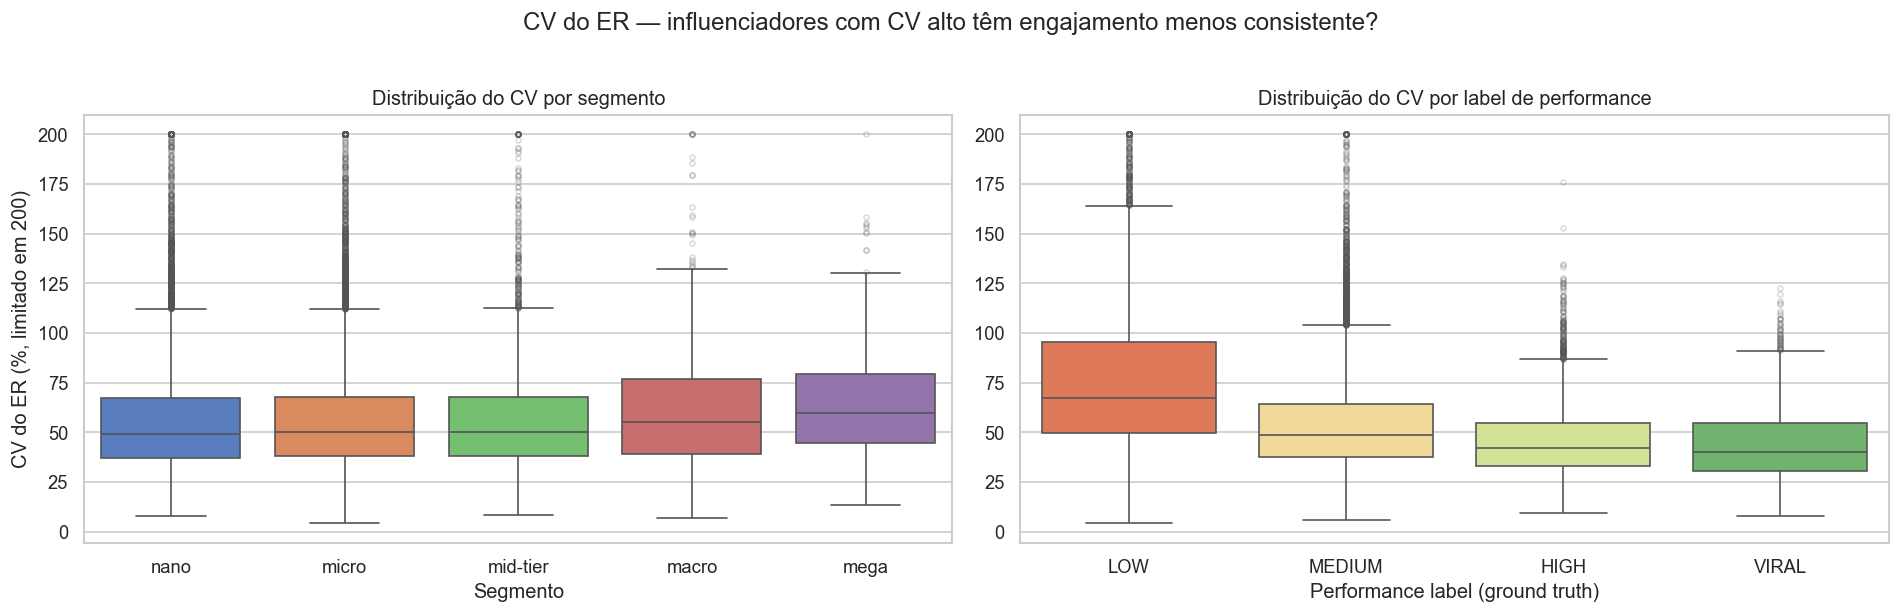

In [46]:
cv_pd = df_val.filter(pl.col("cv_er").is_not_null()).to_pandas()
cv_pd["cv_clip"] = cv_pd["cv_er"].clip(upper=200)  # limita outliers extremos para visualização

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=cv_pd, x="bucket_followers", y="cv_clip",
            order=ORDEM_BUCKET, ax=axes[0], palette="muted",
            flierprops={"marker": ".", "alpha": 0.2})
axes[0].set_title("Distribuição do CV por segmento")
axes[0].set_ylabel("CV do ER (%, limitado em 200)")
axes[0].set_xlabel("Segmento")

sns.boxplot(data=cv_pd, x="performance_label", y="cv_clip",
            order=ORDEM_LABEL, ax=axes[1], palette="RdYlGn",
            flierprops={"marker": ".", "alpha": 0.2})
axes[1].set_title("Distribuição do CV por label de performance")
axes[1].set_ylabel("")
axes[1].set_xlabel("Performance label (ground truth)")

plt.suptitle("CV do ER — influenciadores com CV alto têm engajamento menos consistente?",
             y=1.02)
plt.tight_layout()
plt.show()

## 2.2 Curva f_cv

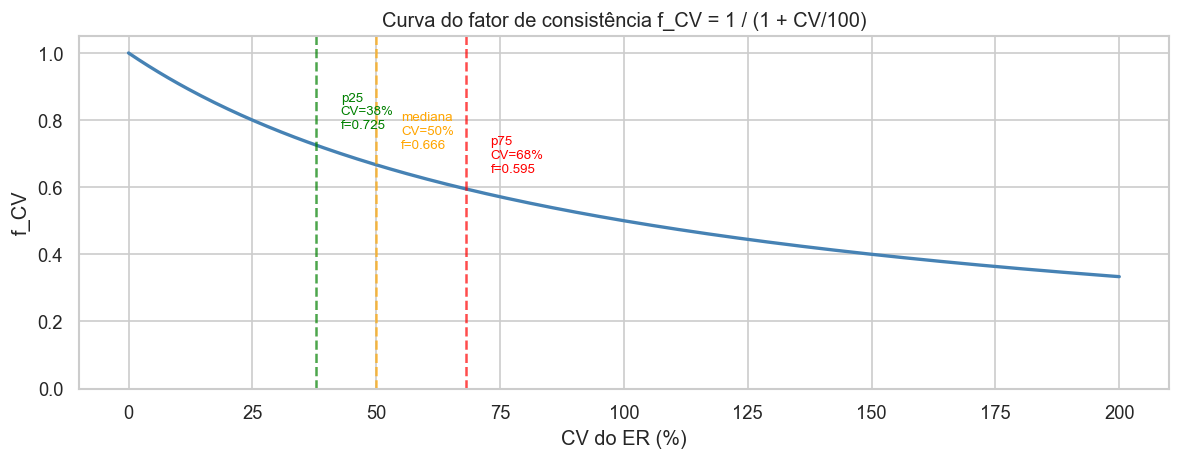

CV=0%   → f_CV=1.000 (sem penalidade)
CV=50%  → f_CV=0.667 (desconto de 33%)
CV=100% → f_CV=0.500 (desconto de 50%)
CV=200% → f_CV=0.333 (desconto de 67%)


In [47]:
cv_range = np.linspace(0, 200, 300)
f_cv_range = 1 / (1 + cv_range / 100)

cv_p25  = float(df_val["cv_er"].quantile(0.25))
cv_med  = float(df_val["cv_er"].median())
cv_p75  = float(df_val["cv_er"].quantile(0.75))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cv_range, f_cv_range, color="steelblue", linewidth=2)

for cv_val, label, color in [(cv_p25, "p25", "green"),
                              (cv_med, "mediana", "orange"),
                              (cv_p75, "p75", "red")]:
    f_val = 1 / (1 + cv_val / 100)
    ax.axvline(cv_val, color=color, linestyle="--", alpha=0.7)
    ax.annotate(f"{label}\nCV={cv_val:.0f}%\nf={f_val:.3f}",
                xy=(cv_val, f_val), xytext=(cv_val + 5, f_val + 0.05),
                fontsize=8, color=color)

ax.set_xlabel("CV do ER (%)")
ax.set_ylabel("f_CV")
ax.set_title("Curva do fator de consistência f_CV = 1 / (1 + CV/100)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"CV=0%   → f_CV={1/(1+0/100):.3f} (sem penalidade)")
print(f"CV=50%  → f_CV={1/(1+50/100):.3f} (desconto de {(1-1/(1+50/100))*100:.0f}%)")
print(f"CV=100% → f_CV={1/(1+100/100):.3f} (desconto de {(1-1/(1+100/100))*100:.0f}%)")
print(f"CV=200% → f_CV={1/(1+200/100):.3f} (desconto de {(1-1/(1+200/100))*100:.0f}%)")

## 2.3 f_cv melhora a separação entre grupos?

In [49]:
df_fcv = df_val.with_columns(
    (1 / (1 + pl.col("cv_er") / 100)).alias("f_cv")
).with_columns(
    (pl.col("er_cl_mediano") * pl.col("f_cv")).alias("er_x_fcv")
).filter(pl.col("cv_er").is_not_null()).to_pandas()

for col, nome in [("er_cl_mediano", "er_classico puro"),
                  ("er_wt_mediano", "er_weighted puro"),
                  ("er_x_fcv",      "er_classico × f_CV")]:
    grupos = [df_fcv[df_fcv["performance_label"] == l][col].values
              for l in ORDEM_LABEL if len(df_fcv[df_fcv["performance_label"] == l]) > 0]
    H, p = kruskal(*grupos)
    print(f"{nome:<25} H={H:>10.2f}  p={p:.2e}")

er_classico puro          H=  25128.08  p=0.00e+00
er_weighted puro          H=  25113.61  p=0.00e+00
er_classico × f_CV        H=  24615.32  p=0.00e+00


# Validação do f_sponsored

f_sponsored = 1-a*pct_sponsored

Hipotese: Quanto maior a proportção de posts patrocinados indica menor autenticidade da audiência, que deve penalizar no IQA.

In [52]:
delta_spon = (
    df_posts.filter(pl.col("er_classico") > 0)
    .group_by(["inf_category", "is_sponsored"])
    .agg(pl.col("er_classico").median().round(4).alias("er_mediano"))
    .to_pandas()
    .pivot_table(index="inf_category", columns="is_sponsored",
                 values="er_mediano")
    .rename(columns={False: "organico", True: "patrocinado"})
)
delta_spon["delta"]    = (delta_spon["patrocinado"] - delta_spon["organico"]).round(4)
delta_spon["delta_pct"] = (delta_spon["delta"] / delta_spon["organico"] * 100).round(2)
print("Delta ER (patrocinado - orgânico) por categoria:")
print(delta_spon.sort_values("delta"))

Delta ER (patrocinado - orgânico) por categoria:
is_sponsored  organico  patrocinado   delta  delta_pct
inf_category                                          
travel          3.6103       3.0674 -0.5429     -15.04
pet             3.6839       3.2116 -0.4723     -12.82
interior        2.4497       2.0329 -0.4168     -17.01
fashion         3.4271       3.1088 -0.3183      -9.29
food            2.4254       2.1272 -0.2982     -12.29
fitness         2.9683       2.7046 -0.2637      -8.88
other           1.9507       1.7256 -0.2251     -11.54
beauty          2.7872       2.6468 -0.1404      -5.04
family          3.2282       3.1107 -0.1175      -3.64


## 3.2 Calibração do a por categoria

f_sponsored = 1- a * pct_sponsores, a E [0.0 , 0.6]

In [54]:
ALPHAS = np.arange(0.0, 0.65, 0.05).round(2)

df_spon = df_val.with_columns(
    (1 / (1 + pl.col("cv_er") / 100)).alias("f_cv")
).filter(pl.col("cv_er").is_not_null()).to_pandas()

resultados_alpha = []
for alpha in ALPHAS:
    df_spon["f_sp"]  = (1 - alpha * df_spon["pct_sponsored"]).clip(lower=0)
    df_spon["er_iqa"] = df_spon["er_wt_mediano"] * df_spon["f_cv"] * df_spon["f_sp"]
    grupos = [df_spon[df_spon["performance_label"] == l]["er_iqa"].values
              for l in ORDEM_LABEL if len(df_spon[df_spon["performance_label"] == l]) > 0]
    H, p = kruskal(*grupos)
    resultados_alpha.append({"alpha": alpha, "H": round(H, 2), "p": p})

df_alpha = pd.DataFrame(resultados_alpha)
print("Grid search do α (f_sponsored = 1 − α × pct_sponsored):")
print(df_alpha.to_string(index=False))
melhor_alpha = df_alpha.loc[df_alpha["H"].idxmax(), "alpha"]
print(f"\nMelhor a global: {melhor_alpha}  (H={df_alpha['H'].max():.2f})")

Grid search do α (f_sponsored = 1 − α × pct_sponsored):
 alpha        H   p
  0.00 24601.38 0.0
  0.05 24601.89 0.0
  0.10 24601.30 0.0
  0.15 24599.18 0.0
  0.20 24595.73 0.0
  0.25 24590.34 0.0
  0.30 24583.40 0.0
  0.35 24574.80 0.0
  0.40 24563.88 0.0
  0.45 24550.83 0.0
  0.50 24535.10 0.0
  0.55 24516.45 0.0
  0.60 24494.61 0.0

Melhor a global: 0.05  (H=24601.89)


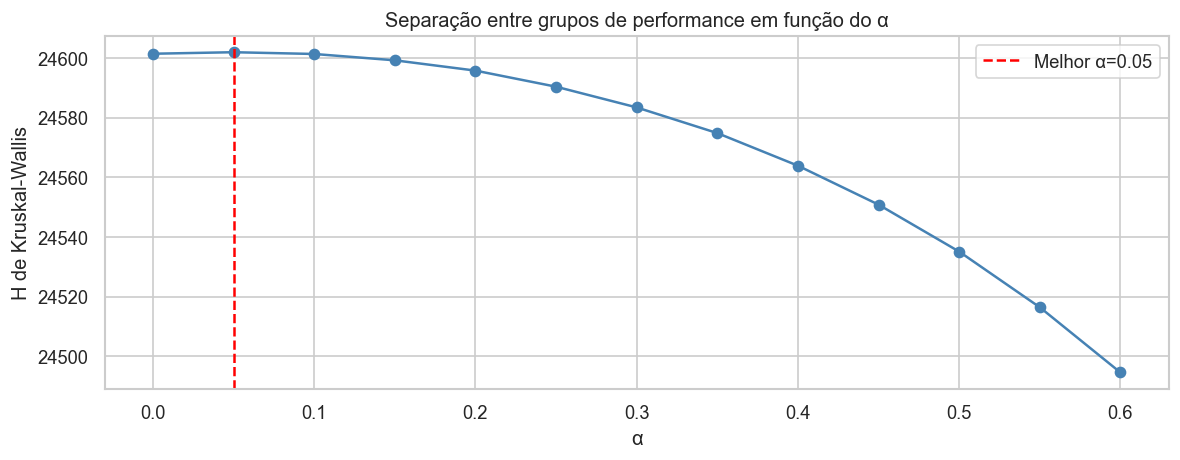

In [55]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_alpha["alpha"], df_alpha["H"], marker="o", color="steelblue")
ax.axvline(melhor_alpha, color="red", linestyle="--",
           label=f"Melhor α={melhor_alpha}")
ax.set_xlabel("α")
ax.set_ylabel("H de Kruskal-Wallis")
ax.set_title("Separação entre grupos de performance em função do α")
ax.legend()
plt.tight_layout()
plt.show()

## 3.3 f_sponsored melhora o ranking?

In [56]:
LABEL_NUM = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "VIRAL": 3}

df_rank = df_spon.copy()
df_rank["gt_num"]  = df_rank["performance_label"].map(LABEL_NUM)
df_rank["f_sp_opt"] = (1 - melhor_alpha * df_rank["pct_sponsored"]).clip(lower=0)
df_rank["f_cv_val"] = 1 / (1 + df_rank["cv_er"] / 100)

df_rank["iqa_v0"] = df_rank["er_wt_mediano"]                                         # só ER
df_rank["iqa_v1"] = df_rank["er_wt_mediano"] * df_rank["f_cv_val"]                   # + f_CV
df_rank["iqa_v2"] = df_rank["er_wt_mediano"] * df_rank["f_cv_val"] * df_rank["f_sp_opt"]  # + f_sponsored

print("Correlação de Spearman com o ground truth (label numérico):")
for col, nome in [("er_cl_mediano", "er_classico puro"),
                  ("iqa_v0",        "er_weighted puro"),
                  ("iqa_v1",        "er_wt x f_CV"),
                  ("iqa_v2",        "er_wt x f_CV x f_sponsored (IQA)")]:
    r, p = spearmanr(df_rank[col], df_rank["gt_num"])
    print(f"  {nome:<38} r={r:.4f}  p={p:.2e}")

Correlação de Spearman com o ground truth (label numérico):
  er_classico puro                       r=0.8711  p=0.00e+00
  er_weighted puro                       r=0.8708  p=0.00e+00
  er_wt x f_CV                           r=0.8619  p=0.00e+00
  er_wt x f_CV x f_sponsored (IQA)       r=0.8619  p=0.00e+00


# 4.0 Validação do IQA Composto

IQA = er_weighted_mediano × f_CV × f_sponsored

## 4.1 Calculo de IQA e distribuição

In [57]:
ALPHA_FINAL = melhor_alpha   # determinado empiricamente na seção 3.2

df_iqa = (
    df_val
    .with_columns([
        (1 / (1 + pl.col("cv_er") / 100)).alias("f_cv"),
        (1 - ALPHA_FINAL * pl.col("pct_sponsored")).clip(lower_bound=0).alias("f_sponsored"),
    ])
    .with_columns(
        (pl.col("er_wt_mediano") * pl.col("f_cv") * pl.col("f_sponsored"))
        .round(6)
        .alias("iqa")
    )
    .filter(pl.col("cv_er").is_not_null())
)

print(f"Influenciadores com IQA calculado: {df_iqa.shape[0]:,}")
print()
print("Estatísticas do IQA:")
print(df_iqa["iqa"].describe())

Influenciadores com IQA calculado: 33,113

Estatísticas do IQA:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 33113.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 2.570242 │
│ std        ┆ 2.271197 │
│ min        ┆ 0.001872 │
│ 25%        ┆ 1.047276 │
│ 50%        ┆ 1.962505 │
│ 75%        ┆ 3.386147 │
│ max        ┆ 42.81327 │
└────────────┴──────────┘


- Bucket de IQA usando os mesmos thresholds do gt

Distribuição do IQA bucket (esperado: pirâmide 25/50/15/10):
shape: (4, 3)
┌────────────┬───────┬──────┐
│ iqa_bucket ┆ n     ┆ pct  │
│ ---        ┆ ---   ┆ ---  │
│ str        ┆ u32   ┆ f64  │
╞════════════╪═══════╪══════╡
│ LOW        ┆ 8278  ┆ 25.0 │
│ MEDIUM     ┆ 16556 ┆ 50.0 │
│ HIGH       ┆ 4967  ┆ 15.0 │
│ VIRAL      ┆ 3312  ┆ 10.0 │
└────────────┴───────┴──────┘


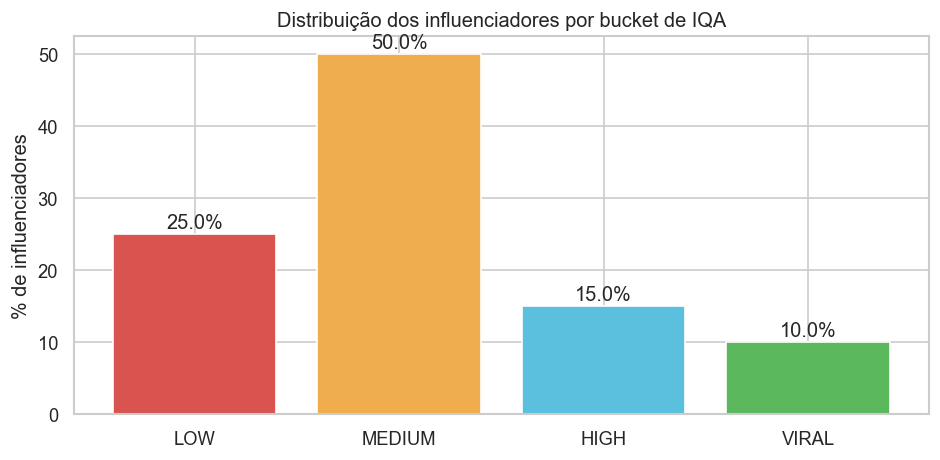

In [58]:
iqa_p25 = float(df_iqa["iqa"].quantile(0.25))
iqa_p75 = float(df_iqa["iqa"].quantile(0.75))
iqa_p90 = float(df_iqa["iqa"].quantile(0.90))

df_iqa = df_iqa.with_columns(
    pl.when(pl.col("iqa") < iqa_p25)  .then(pl.lit("LOW"))
    .when(pl.col("iqa") < iqa_p75)    .then(pl.lit("MEDIUM"))
    .when(pl.col("iqa") < iqa_p90)    .then(pl.lit("HIGH"))
    .otherwise(                         pl.lit("VIRAL"))
    .alias("iqa_bucket")
)

dist_iqa = (
    df_iqa.group_by("iqa_bucket")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / df_iqa.shape[0] * 100).round(1).alias("pct"))
    .sort(pl.col("iqa_bucket").cast(pl.Enum(ORDEM_IQA)))
)
print("Distribuição do IQA bucket (esperado: pirâmide 25/50/15/10):")
print(dist_iqa)

fig, ax = plt.subplots(figsize=(8, 4))
cores = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c"]
vals  = dist_iqa.sort(pl.col("iqa_bucket").cast(pl.Enum(ORDEM_IQA)))
ax.bar(vals["iqa_bucket"].to_list(), vals["pct"].to_list(), color=cores)
for bar, pct in zip(ax.patches, vals["pct"].to_list()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom")
ax.set_ylabel("% de influenciadores")
ax.set_title("Distribuição dos influenciadores por bucket de IQA")
plt.tight_layout()
plt.show()

## 4.2 IQA vs GT

Correlação Spearman IQA × ground truth: r=0.8619  p=0.00e+00


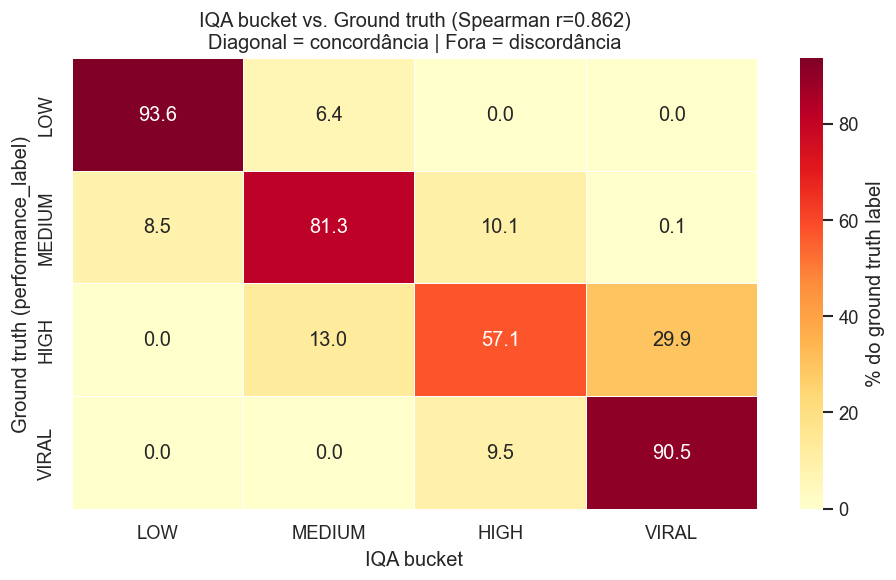


Concordância exata (mesmo bucket): 26762 (80.8%)
Discordância:                      6351 (19.2%)


In [60]:
iqa_pd = df_iqa.to_pandas()
iqa_pd["gt_num"]  = iqa_pd["performance_label"].map(LABEL_NUM)
iqa_pd["iqa_num"] = iqa_pd["iqa_bucket"].map(LABEL_NUM)

r_iqa, p_iqa = spearmanr(iqa_pd["iqa"], iqa_pd["gt_num"])
print(f"Correlação Spearman IQA × ground truth: r={r_iqa:.4f}  p={p_iqa:.2e}")

contingencia = (
    iqa_pd.pivot_table(index="performance_label", columns="iqa_bucket",
                       values="username", aggfunc="count", fill_value=0)
    .reindex(index=ORDEM_LABEL, columns=ORDEM_IQA, fill_value=0)
)
contingencia_pct = (contingencia.div(contingencia.sum(axis=1), axis=0) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(contingencia_pct, ax=ax, cmap="YlOrRd",
            annot=True, fmt=".1f", linewidths=0.4,
            cbar_kws={"label": "% do ground truth label"})
ax.set_title(
    f"IQA bucket vs. Ground truth (Spearman r={r_iqa:.3f})\n"
    "Diagonal = concordância | Fora = discordância"
)
ax.set_xlabel("IQA bucket")
ax.set_ylabel("Ground truth (performance_label)")
plt.tight_layout()
plt.show()

n_total = len(iqa_pd)
n_concord = sum(contingencia.values[i][i] for i in range(len(ORDEM_LABEL)))
print(f"\nConcordância exata (mesmo bucket): {n_concord} ({n_concord/n_total*100:.1f}%)")
print(f"Discordância:                      {n_total-n_concord} ({(n_total-n_concord)/n_total*100:.1f}%)")

## 4.3 Analise segmentada - categoria e bucket de followers

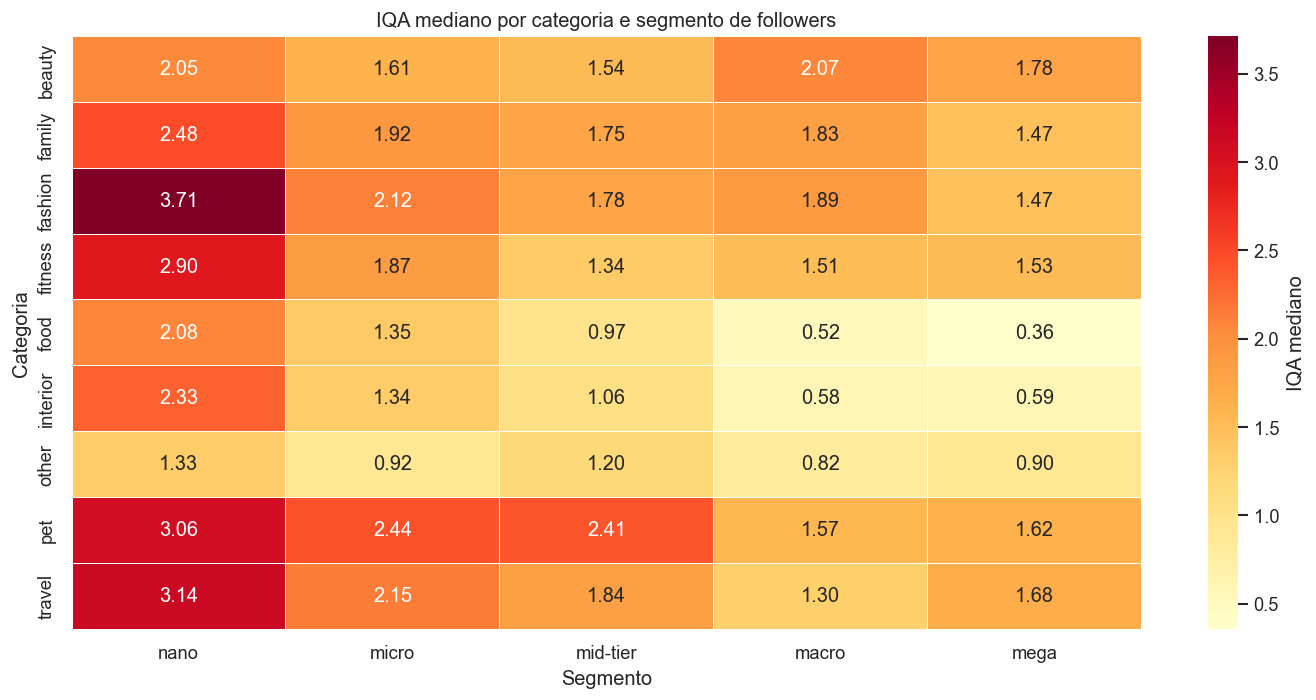

In [62]:
iqa_seg = (
    df_iqa
    .group_by(["categoria", "bucket_followers"])
    .agg([
        pl.col("iqa").median().round(4).alias("iqa_mediano"),
        pl.col("iqa").mean().round(4).alias("iqa_medio"),
        pl.len().alias("n"),
    ])
    .to_pandas()
)

pivot_iqa = (
    iqa_seg.pivot_table(index="categoria", columns="bucket_followers",
                        values="iqa_mediano")
    [ORDEM_BUCKET]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_iqa, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            linewidths=0.3, cbar_kws={"label": "IQA mediano"})
ax.set_title("IQA mediano por categoria e segmento de followers")
ax.set_xlabel("Segmento")
ax.set_ylabel("Categoria")
plt.tight_layout()


## 4.4 Validação hold-out

In [64]:
np.random.seed(42)
usernames = df_iqa["username"].to_numpy()
np.random.shuffle(usernames)
split     = int(len(usernames) * 0.8)
treino    = set(usernames[:split])
teste     = set(usernames[split:])

df_treino = df_iqa.filter(pl.col("username").is_in(list(treino)))
df_teste  = df_iqa.filter(pl.col("username").is_in(list(teste)))

# Thresholds de IQA calculados apenas no treino
iqa_p25_tr = float(df_treino["iqa"].quantile(0.25))
iqa_p75_tr = float(df_treino["iqa"].quantile(0.75))
iqa_p90_tr = float(df_treino["iqa"].quantile(0.90))

# Aplica no teste
df_teste_eval = df_teste.with_columns(
    pl.when(pl.col("iqa") < iqa_p25_tr)  .then(pl.lit("LOW"))
    .when(pl.col("iqa") < iqa_p75_tr)    .then(pl.lit("MEDIUM"))
    .when(pl.col("iqa") < iqa_p90_tr)    .then(pl.lit("HIGH"))
    .otherwise(                            pl.lit("VIRAL"))
    .alias("iqa_bucket_holdout")
).to_pandas()

df_teste_eval["gt_num"]       = df_teste_eval["performance_label"].map(LABEL_NUM)
df_teste_eval["iqa_bucket_num"] = df_teste_eval["iqa_bucket_holdout"].map(LABEL_NUM)

r_test, p_test = spearmanr(df_teste_eval["iqa"], df_teste_eval["gt_num"])
r_train_pd = df_treino.to_pandas()
r_train_pd["gt_num"] = r_train_pd["performance_label"].map(LABEL_NUM)
r_train, _ = spearmanr(r_train_pd["iqa"], r_train_pd["gt_num"])

print(f"Correlação IQA × GT — treino (80%): r={r_train:.4f}")
print(f"Correlação IQA × GT — teste  (20%): r={r_test:.4f}")
print()
n_concord_test = (df_teste_eval["iqa_bucket_holdout"] == df_teste_eval["performance_label"]).sum()
print(f"Concordância exata no teste: {n_concord_test} ({n_concord_test/len(df_teste_eval)*100:.1f}%)")


Correlação IQA × GT — treino (80%): r=0.8628
Correlação IQA × GT — teste  (20%): r=0.8580

Concordância exata no teste: 5319 (80.3%)


## 4.5 Analise de sentimento dos comentários
Sessão futura se houver tempo

# 5.0 Conclusões e salvamento do parquet

In [66]:
iqa_pd = df_iqa.to_pandas()
iqa_pd["gt_num"] = iqa_pd["performance_label"].map(LABEL_NUM)

versoes = [
    ("er_classico puro",       iqa_pd["er_cl_mediano"]),
    ("er_weighted puro",       iqa_pd["er_wt_mediano"]),
    ("+ f_CV",                 iqa_pd["er_wt_mediano"] * (1/(1+iqa_pd["cv_er"]/100))),
    ("+ f_CV + f_sponsored",   iqa_pd["er_wt_mediano"] * (1/(1+iqa_pd["cv_er"]/100))
                               * (1 - ALPHA_FINAL * iqa_pd["pct_sponsored"]).clip(lower=0)),
]

print("Evolução da correlação com o ground truth (Spearman r):")
print(f"{'Versão':<30} {'r':>8} {'p':>12}")
print("-" * 55)
for nome, serie in versoes:
    r, p = spearmanr(serie, iqa_pd["gt_num"])
    print(f"{nome:<30} {r:>8.4f} {p:>12.2e}")

# print()
# print(f"Parâmetros finais adotados:")
# print(f"  er_weighted: (likes×1 + comments×2) / followers × 100")
# print(f"  f_CV:        1 / (1 + CV/100)")
# print(f"  f_sponsored: 1 - {ALPHA_FINAL} × pct_sponsored  (α calibrado empiricamente)")
# print(f"  IQA:         er_weighted_mediano × f_CV × f_sponsored")

Evolução da correlação com o ground truth (Spearman r):
Versão                                r            p
-------------------------------------------------------
er_classico puro                 0.8711     0.00e+00
er_weighted puro                 0.8708     0.00e+00
+ f_CV                           0.8619     0.00e+00
+ f_CV + f_sponsored             0.8619     0.00e+00


In [ ]:
df_iqa.write_parquet("influenciadores_iqa.parquet", compression="zstd")
print(f"Salvo: influenciadores_iqa.parquet")
print(f"Shape: {df_iqa.shape[0]:,} x {df_iqa.shape[1]} colunas")
print()
print("Colunas:")
print(df_iqa.columns)